**Phase 1: Exploratory Data Analysis (EDA)**

In [ ]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

print("Rows, Columns:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nData Types")
print(df.dtypes)

Rows, Columns: (9994, 21)

Missing Values
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate Rows
0

Data Types
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit          

**KPI Analysis**

In [ ]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

print("Total Sales :", round(total_sales,2))
print("Total Profit :", round(total_profit,2))
print("Total Orders :", total_orders)
print("Total Customers :", total_customers)

Total Sales : 2297200.86
Total Profit : 286397.02
Total Orders : 5009
Total Customers : 793


**Top 10 Products**

In [ ]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


**Region-wise Sales**

In [ ]:
print(
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


**Category-wise Sales**

In [ ]:
print(
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


**Monthly Sales Trend**

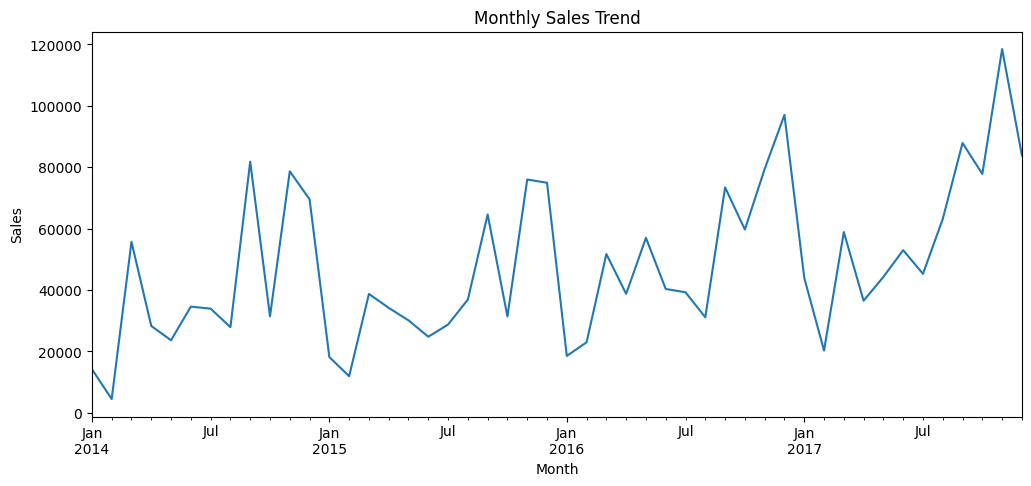

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

**Sales vs Profit**

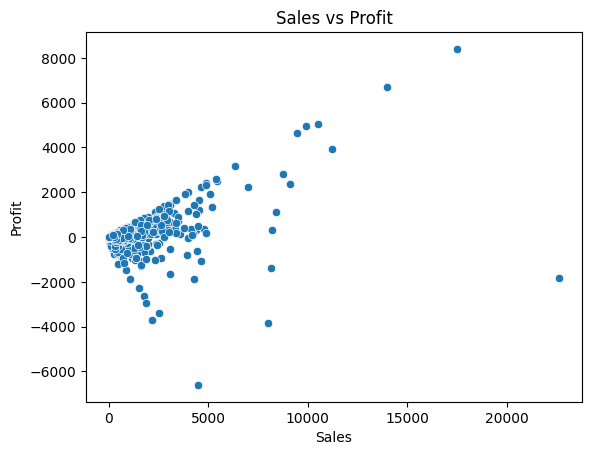

In [ ]:
import seaborn as sns

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit"
)

plt.title("Sales vs Profit")
plt.show()

**Discount Impact on Profit**

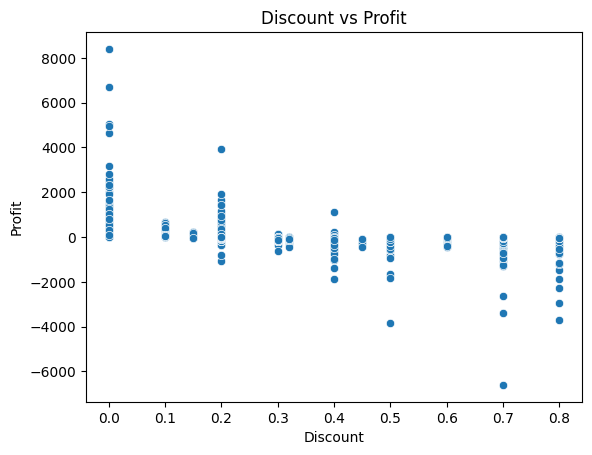

In [ ]:
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.show()

**Top 10 States by Sales**

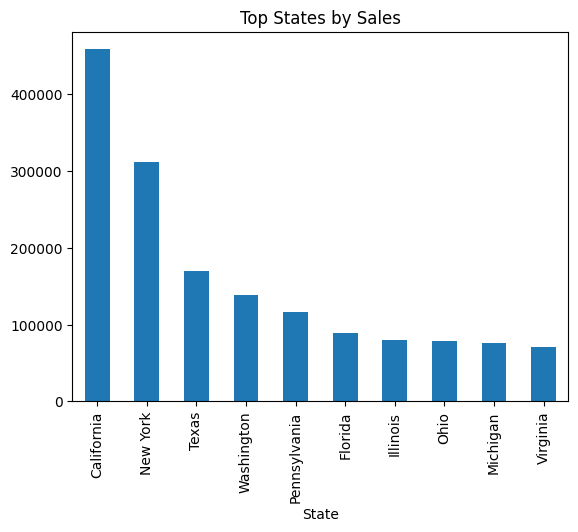

In [ ]:
top_states = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_states.plot(kind="bar")
plt.title("Top States by Sales")
plt.show()

**Most Profitable States**

In [ ]:
profit_states = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(profit_states)

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64


**Category Profit Analysis**

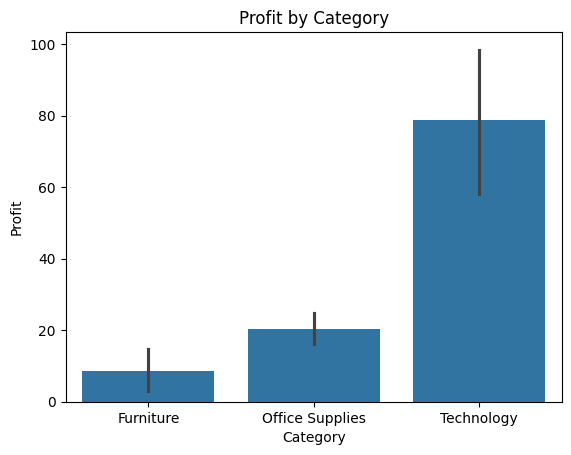

In [ ]:
sns.barplot(
    data=df,
    x="Category",
    y="Profit"
)

plt.title("Profit by Category")
plt.show()

**Customer Segmentation**

In [ ]:
customer_sales = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(customer_sales)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64
